# **Browser Use Agent with LLM: CourseWhisperer**


# Concept

An intelligent browser automation agent that leverages LLM to navigate [DeepLearning.AI's](https://www.deeplearning.ai/) course catalog, analyze course offerings, and provide personalized learning paths from Andrew Ng's educational platform.

# Technical Stack
- Uses Together.ai's LLaMA model for analyzing DeepLearning.AI's course content
- Executes browser automation safely with [Playwright](https://playwright.dev/) to navigate DeepLearning.AI website


# Flow Chart

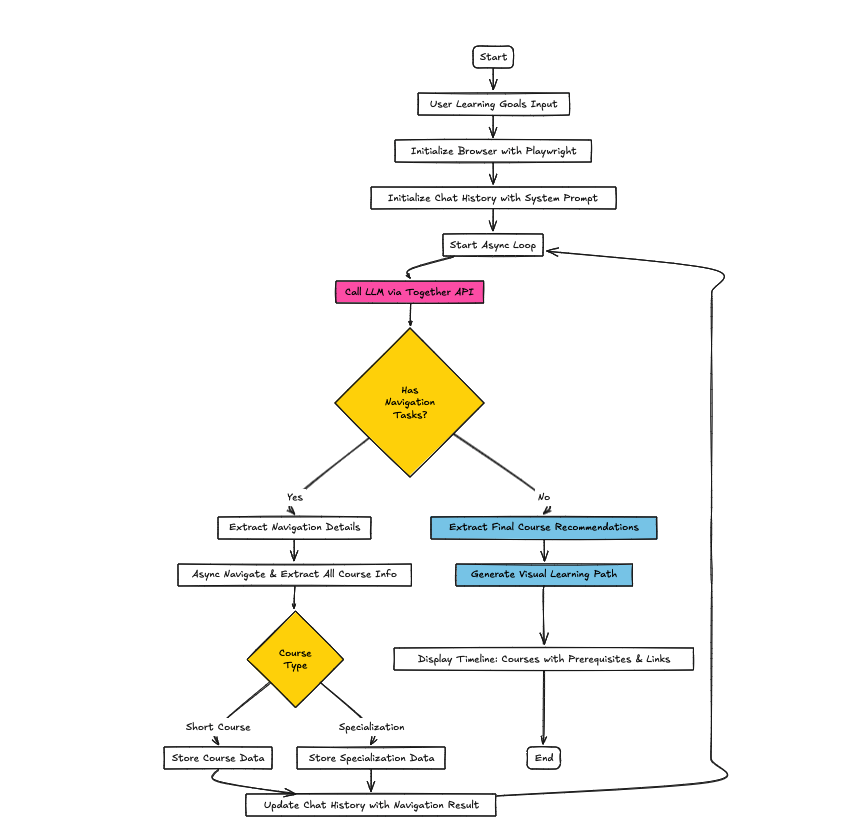

# Install the required packages


In [ ]:
!pip install playwright
!playwright install --with-deps chromium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 MB 15.2 MB/s eta 0:00:00
Installing dependencies...
Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,561 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,619 kB]
Hit:12 https://ppa.launchpadcontent.n

# Imports and Setup

In [ ]:
import asyncio  # For async/await functionality
from playwright.async_api import async_playwright, TimeoutError  # For web automation
from openai import OpenAI  # For AI interactions
from google.colab import userdata  # To get API keys securely
from IPython.display import display, HTML  # For displaying content in notebook
import base64  # For encoding screenshots
import json  # For handling JSON data
from pprint import pprint  # For pretty printing data structures

In [ ]:
# Initialize OpenAI client with Together.ai's API
client = OpenAI(
    base_url="https://api.together.xyz/v1",
    api_key=userdata.get("TOGETHER_API_KEY")
)

### Define the tools that our Agent can use to interact with the browser

In [ ]:
tools = [
    {
        "type": "function",
        "function": {
            "name": "load_page",
            "description": "Load a webpage and return clickable elements",
            "parameters": {
                "type": "object",
                "properties": {
                    "url": {
                        "type": "string",
                        "description": "URL to load"
                    }
                },
                "required": ["url"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "click_element",
            "description": "Click an element by its ID",
            "parameters": {
                "type": "object",
                "properties": {
                    "element_id": {
                        "type": "integer",
                        "description": "ID of element to click"
                    }
                },
                "required": ["element_id"]
            }
        }
    }
]

## Helper Functions

In [ ]:
# Function to get all clickable elements from a webpage
async def get_page_elements(page):
    """
    Scans the webpage and returns information about all clickable elements
    Returns: List of dictionaries containing element properties (id, text, tag, href)
    """
    try:
        # Execute JavaScript in the browser to find elements
        elements = await page.evaluate("""() => {
            // Select all potentially clickable elements
            const clickableElements = Array.from(document.querySelectorAll('a, button, [role="button"]'));

            // Filter and map elements to get their properties
            return clickableElements
                .filter(el => {
                    // Only get visible elements
                    const rect = el.getBoundingClientRect();
                    return el.offsetParent !== null && rect.width > 0 && rect.height > 0;
                })
                .map((el, index) => ({
                    id: index,  // Assign unique ID to each element
                    text: el.innerText.trim(),  // Get element's text
                    tag: el.tagName.toLowerCase(),  // Get HTML tag (a, button, etc)
                    href: el.href || ''  // Get link URL if it exists
                }))
                .filter(item => item.text);  // Only keep elements with text
        }""")
        return elements
    except Exception as e:
        print(f"Error getting elements: {e}")
        return []

In [ ]:
# Function to display current page state with screenshot
async def display_step(title, screenshot, elements=None):
    """
    Creates a visual display of the current page state
    Parameters:
        title: Step description
        screenshot: Page screenshot
        elements: List of clickable elements found
    """
    display(HTML("""
        <div style="margin: 20px; padding: 20px; border: 1px solid #ddd; border-radius: 10px;">
            <h3 style="color: #2c3e50;">{}</h3>
            <div style="margin: 20px 0;">
                <img src="data:image/png;base64,{}"
                     style="max-width: 100%; border: 1px solid #ddd;">
            </div>
            {}
        </div>
    """.format(
        title,  # Display step title
        base64.b64encode(screenshot).decode(),  # Display encoded screenshot
        # If elements exist, create a list of clickable elements
        """
            <div style="margin-top: 20px;">
                <h4>Clickable Elements:</h4>
                <ul style="list-style-type: none; padding: 0;">
                    {}
                </ul>
            </div>
        """.format(''.join([
            """
            <li style="padding: 10px; border-bottom: 1px solid #eee;">
                <strong>ID {}</strong>: {}
                <span style="color: #666;">
                    ({}{})
                </span>
            </li>
            """.format(
                el['id'],
                el['text'],
                el['tag'],
                f" - {el['href']}" if el['href'] else ''
            ) for el in elements
        ])) if elements else ""
    )))

In [ ]:
# Functions that will be called by the Agent to interact with the webpage
async def load_page(url):
    """
    Loads a webpage and gets its clickable elements
    Parameters:
        url: The webpage URL to load
    Returns:
        String describing the loaded page and its clickable elements
    """
    global page, clickable_elements
    # Navigate to the URL and wait for content to load
    await page.goto(url, wait_until="domcontentloaded")
    # Get all clickable elements on the page
    clickable_elements = await get_page_elements(page)

    # Create a dictionary mapping element IDs to their text
    elements_dict = {str(el['id']): el['text'] for el in clickable_elements}
    # Return a description of what's clickable on the page
    return f"The page has loaded and the following element IDs can be clicked{json.dumps(elements_dict)}"

async def click_element(element_id):
    """
    Clicks an element on the page by its ID
    Parameters:
        element_id: The ID of the element to click
    Returns:
        String describing the new page state after clicking
    """
    global page, clickable_elements
    # Check if element_id is valid
    if 0 <= element_id < len(clickable_elements):
        # Click the element and wait for page to load
        await page.click(f"text={clickable_elements[element_id]['text']}")
        await page.wait_for_load_state("domcontentloaded")
        # Get new set of clickable elements after page change
        clickable_elements = await get_page_elements(page)

        # Create updated dictionary of clickable elements
        elements_dict = {str(el['id']): el['text'] for el in clickable_elements}
        return f"The page has loaded and the following element IDs can be clicked{json.dumps(elements_dict)}"
    return "Invalid element ID"

## Recommendations Function

In [ ]:
async def get_recommendations(query, courses, num_recommendations=5):
    """
    Gets course recommendations based on user query
    Parameters:
        query: User's learning goals
        courses: List of available courses
        num_recommendations: Number of courses to recommend
    Returns:
        List of recommended courses with explanations
    """
    try:
        # Format courses data for the AI
        courses_data = "\n".join([
            f"Title: {c['title']}\nType: {c['type']}\nDescription: {c['description']}\n"
            for c in courses
        ])

        # Create detailed prompt for the AI
        prompt = f"""As an AI learning path expert, analyze this learner's query: "{query}"

Available courses:
{courses_data}

Create an optimal {num_recommendations}-step learning path that:
1. Matches the learner's current skill level
2. Follows a logical progression from basics to advanced concepts
3. Ensures each course builds upon knowledge from previous courses
4. Considers practical applications and hands-on experience
5. Aligns with the learner's stated goals

For each recommended course:
- Explain why it's the right choice for that specific learning stage
- Describe how it connects to previous/next courses
- Highlight specific skills or concepts the learner will gain
- Explain how it contributes to their overall learning goals

Format each recommendation exactly as:
STEP 1: [Exact Course Title] | [Detailed explanation including prerequisites, key learnings, and connection to learning journey]
STEP 2: [Exact Course Title] | [Explanation...]
...and so on up to STEP {num_recommendations}

Important:
- Use exact course titles from the available list
- Focus on creating a coherent learning progression
- Consider both theoretical knowledge and practical application
- Include courses of different types (Short Courses, Courses, Specializations) where appropriate
"""

        # Get AI response
        response = client.chat.completions.create(
            model="meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.7,
            max_tokens=2048
        )

        # Process AI response
        content = response.choices[0].message.content.strip()
        print(f"Debug - AI Response: {content}")

        # Parse recommendations
        recommendations = []
        seen_titles = set()

        # Process each line of the response
        for line in content.split('\n'):
            if 'STEP' in line and '|' in line:
                try:
                    # Split into title and explanation
                    parts = line.split('|', 1)
                    course_title = parts[0].split(':', 1)[1].strip()
                    reason = parts[1].strip()

                    # Find best matching course
                    best_match = None
                    highest_similarity = 0

                    for course in courses:
                        # Skip already recommended courses
                        if course['title'] in seen_titles:
                            continue

                        # Compare titles
                        course_title_lower = course_title.lower()
                        current_title_lower = course['title'].lower()

                        # Check for exact match first
                        if course_title_lower in current_title_lower or current_title_lower in course_title_lower:
                            best_match = course
                            break

                        # Fallback to word matching
                        common_words = len(set(course_title_lower.split()) & set(current_title_lower.split()))
                        similarity = common_words / len(set(course_title_lower.split()))

                        if similarity > highest_similarity:
                            highest_similarity = similarity
                            best_match = course

                    # Add recommendation if match found
                    if best_match and best_match['title'] not in seen_titles:
                        recommendations.append({
                            'course': best_match,
                            'reason': reason
                        })
                        seen_titles.add(best_match['title'])

                        if len(recommendations) >= num_recommendations:
                            break

                except Exception as e:
                    print(f"Error parsing line: {line}, Error: {e}")
                    continue

        print(f"Debug - Found {len(recommendations)} recommendations")
        return recommendations

    except Exception as e:
        print(f"Error getting recommendations: {e}")
        return []

##  Main Browser Function

In [ ]:
async def browse_courses(query):
    """
    Main function to browse and extract courses from deeplearning.ai
    Parameters:
        query: User's learning goals/requirements
    Returns:
        List of found courses
    """
    playwright = None
    browser = None

    try:
        # Initialize browser
        playwright = await async_playwright().start()
        browser = await playwright.chromium.launch(
            headless=True,  # Run browser in background
            args=['--disable-dev-shm-usage', '--no-sandbox']  # Required for Colab
        )

        # Create new browser context and page
        context = await browser.new_context()
        page = await context.new_page()
        await page.set_viewport_size({"width": 1280, "height": 800})

        # Navigate to website
        print("Navigating to deeplearning.ai...")
        await page.goto("https://www.deeplearning.ai/", wait_until="domcontentloaded")
        screenshot = await page.screenshot()
        elements = await get_page_elements(page)
        await display_step("📍 Initial Page Load", screenshot, elements)

        # Find and click courses link
        courses_elements = [el for el in elements if 'course' in el['text'].lower()]
        if courses_elements:
            course_el = courses_elements[0]
            print(f"Clicking on '{course_el['text']}'...")
            await page.click(f"text={course_el['text']}")
            await page.wait_for_load_state('domcontentloaded')
            screenshot = await page.screenshot()
            elements = await get_page_elements(page)

            # Initialize course collection
            courses = []
            seen = set()

            # Extract course information
            for el in elements:
                # Skip navigation and utility elements
                if ('explore' in el['text'].lower() or
                    'view all' in el['text'].lower() or
                    'view course' in el['text'].lower() or
                    el['text'].lower() == 'courses' or
                    'course type' in el['text'].lower()):
                    continue

                # Validate course link
                if not el['href'] or not ('/short-courses/' in el['href'] or '/courses/' in el['href']):
                    continue

                # Skip duplicates
                if el['href'] in seen:
                    continue

                # Process course title and type
                title = el['text'].strip()
                course_type = 'Course'

                if 'short course' in title.lower():
                    course_type = 'Short Course'
                    title = title.replace('Short Course', '').strip()
                elif 'specialization' in title.lower():
                    course_type = 'Specialization'
                    title = title.replace('Specialization', '').strip()

                # Extract course description using JavaScript
                description = await page.evaluate("""(href) => {
                    const link = document.querySelector(`a[href="${href}"]`);
                    if (!link) return '';
                    const parent = link.closest('div');
                    if (!parent) return '';
                    const desc = parent.querySelector('p');
                    return desc ? desc.textContent.trim() : '';
                }""", el['href'])

                seen.add(el['href'])

                # Add course to collection
                courses.append({
                    'title': title,
                    'type': course_type,
                    'description': description,
                    'link': el['href']
                })

            # Get AI recommendations
            recommendations = await get_recommendations(query, courses)

            # Organize courses by type
            course_groups = {}
            for course in courses:
                group = course['type']
                if group not in course_groups:
                    course_groups[group] = []
                course_groups[group].append(course)

            # Sort courses within groups
            for group in course_groups:
                course_groups[group].sort(key=lambda x: x['title'])

            # Generate HTML display content
            html_content = generate_html_content(courses, course_groups, recommendations)

            # Display results
            print(f"\nFound {len(courses)} unique courses")
            display(HTML(html_content))

            return courses

    except Exception as e:
        print(f"Error during browsing: {type(e).__name__}: {e}")
        return []

    finally:
        # Clean up browser resources
        if browser:
            await browser.close()
        if playwright:
            await playwright.stop()

## HTML Generation Function

In [ ]:
def generate_html_content(courses, course_groups, recommendations):
    """
    Generates formatted HTML content for displaying courses and recommendations
    Parameters:
        courses: List of all courses
        course_groups: Courses organized by type
        recommendations: AI-recommended courses
    Returns:
        Formatted HTML string
    """
    # Start with course listing section
    html_content = f"""
        <div style="margin: 20px; padding: 20px; border: 1px solid #ddd; border-radius: 10px;">
            <h3 style="color: #2c3e50;">Found {len(courses)} Unique Courses:</h3>
            <div style="margin-top: 20px; max-height: 600px; overflow-y: auto;">
    """

    # Add each course group
    for group in sorted(course_groups.keys()):
        html_content += f"""
            <div style="margin: 20px 0;">
                <h4 style="color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 5px;">
                    {group}s
                </h4>
        """

        # Add courses in this group
        for course in course_groups[group]:
            html_content += f"""
                <div style="padding: 15px; margin: 10px 0; background: #f8f9fa; border-radius: 5px; border-left: 4px solid #3498db;">
                    <h4 style="margin: 0; color: #2c3e50;">
                        <a href="{course['link']}" target="_blank" style="color: #3498db; text-decoration: none;">
                            {course['title']}
                        </a>
                    </h4>
                    <p style="margin: 10px 0; color: #666;">{course['description']}</p>
                </div>
            """

        html_content += "</div>"

    html_content += "</div></div>"

    # Add recommendations section if available
    if recommendations:
        html_content += generate_recommendations_html(recommendations)

    return html_content

## Recommendations HTML Generation

In [ ]:
def generate_recommendations_html(recommendations):
    """
    Generates HTML for the recommendations section with modern styling
    Parameters:
        recommendations: List of recommended courses with explanations
    Returns:
        Formatted HTML string for recommendations section
    """
    html_content = f"""
        <div style="margin: 40px 20px; padding: 30px; border: 1px solid #e1e4e8; border-radius: 15px;
                    background: linear-gradient(to right, #f8f9fa, #ffffff);">
            <h3 style="color: #2c3e50; margin-bottom: 30px; display: flex; align-items: center; gap: 10px;">
                <span style="background: #3498db; padding: 8px; border-radius: 50%;">
                    <svg width="24" height="24" viewBox="0 0 24 24" fill="white">
                        <path d="M12 2L2 7l10 5 10-5-10-5zM2 17l10 5 10-5M2 12l10 5 10-5"></path>
                    </svg>
                </span>
                Recommended Learning Path
            </h3>
            <div style="display: flex; flex-direction: column; gap: 25px; position: relative;">
                <!-- Vertical timeline line -->
                <div style="position: absolute; left: 24px; top: 0; bottom: 0; width: 2px;
                            background: #2ecc71; z-index: 0;"></div>
    """

    # Add each recommendation with timeline styling
    for i, rec in enumerate(recommendations, 1):
        html_content += f"""
            <div style="position: relative; padding: 25px; background: white; border-radius: 12px;
                        box-shadow: 0 4px 6px rgba(0, 0, 0, 0.05); margin-left: 40px; border: 1px solid #e1e4e8;">
                <!-- Timeline node -->
                <div style="position: absolute; left: -48px; top: 50%; transform: translateY(-50%);
                           background: #2ecc71; color: white; width: 36px; height: 36px;
                           border-radius: 50%; display: flex; align-items: center; justify-content: center;
                           font-weight: bold; font-size: 18px; border: 3px solid white;
                           box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1);">
                    {i}
                </div>
                <h4 style="margin: 0 0 15px 0; color: #2c3e50; font-size: 18px;">
                    <a href="{rec['course']['link']}" target="_blank"
                       style="color: #2ecc71; text-decoration: none; display: flex; align-items: center; gap: 8px;">
                        {rec['course']['title']}
                        <!-- External link icon -->
                        <svg width="16" height="16" viewBox="0 0 24 24" fill="#2ecc71">
                            <path d="M18 13v6a2 2 0 0 1-2 2H5a2 2 0 0 1-2-2V8a2 2 0 0 1 2-2h6m4-3h6v6m-11 5L21 3"></path>
                        </svg>
                    </a>
                </h4>
                <p style="margin: 0; color: #666; line-height: 1.6;">
                    {rec['reason']}
                </p>
            </div>
        """

    html_content += "</div></div>"
    return html_content

## Main Execution

Starting AI Course Explorer...


Navigating to deeplearning.ai...



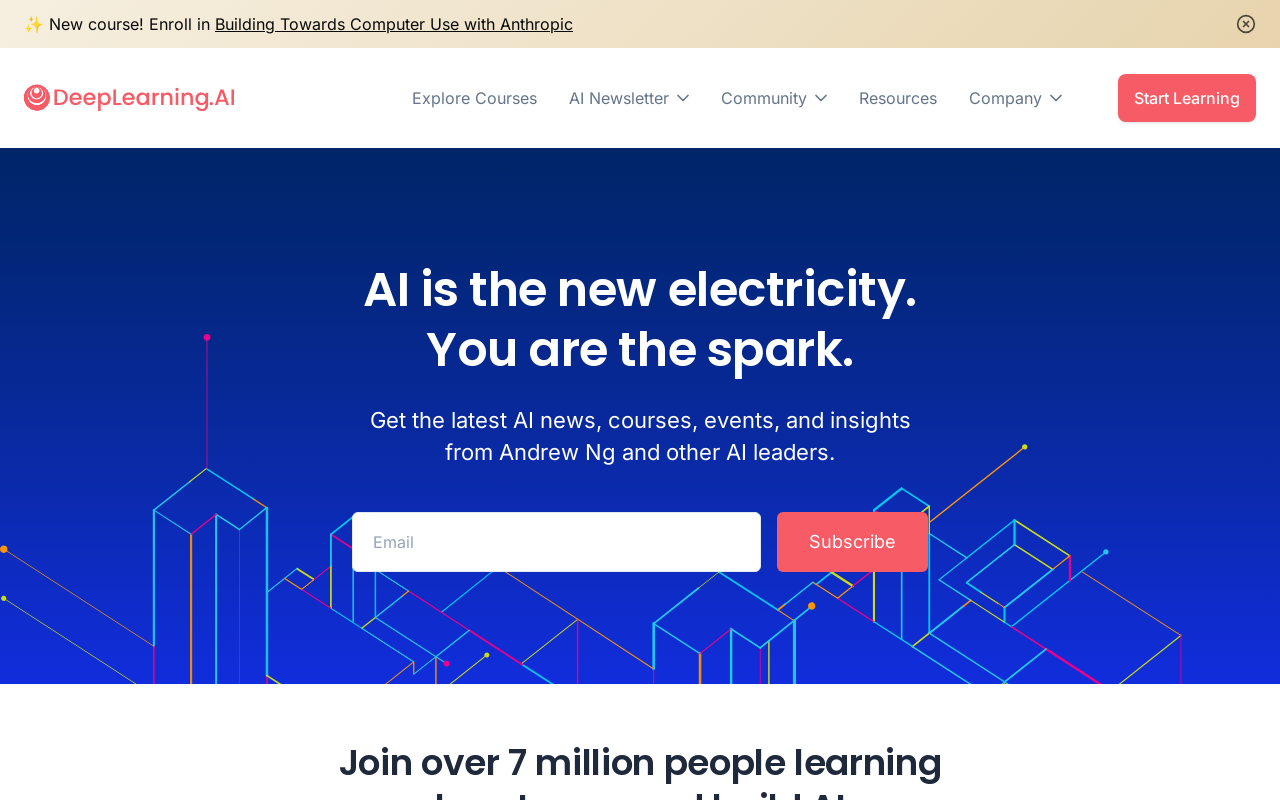

Clicking on 'Explore Courses'...
Debug - AI Response: **Optimal 5-Step Learning Path for a Python Developer Interested in AI and Machine Learning**

**STEP 1: AI Python for Beginners | Foundational AI Concepts and Practical Applications**

This short course is the ideal starting point for a Python developer interested in AI and machine learning. It provides a comprehensive introduction to AI concepts, hands-on experience with real-world applications, and a solid foundation in Python programming with AI assistance. The learner will gain skills in writing, testing, and debugging code efficiently and create practical AI applications.

**Prerequisites:** Basic Python programming skills
**Key Learnings:** Foundational AI concepts, Python programming with AI assistance, real-world AI applications
**Connection to Learning Journey:** This course lays the groundwork for further exploration of AI and machine learning concepts, providing a solid foundation for the next steps in the learning journ

In [ ]:
# Main function to run the course explorer
async def main():
    """
    Main function that initializes the course explorer with a sample query
    """
    # For Python developers interested in AI/ML
    query = """I'm a Python developer interested in learning AI and machine learning.
    I want to start with practical applications and eventually move to more advanced concepts.
    What courses would you recommend?"""

    # Display header with query
    display(HTML("""
        <div style="margin: 20px; padding: 20px; background: linear-gradient(135deg, #3498db, #2c3e50);
                    color: white; border-radius: 15px; text-align: center;">
            <h2>🤖 AI Course Explorer</h2>
            <p>Query: "{}"</p>
        </div>
    """.format(query)))

    # Start course exploration
    courses = await browse_courses(query)

# Run the application
print("Starting AI Course Explorer...")
await main()

Starting AI Course Explorer...


Navigating to deeplearning.ai...



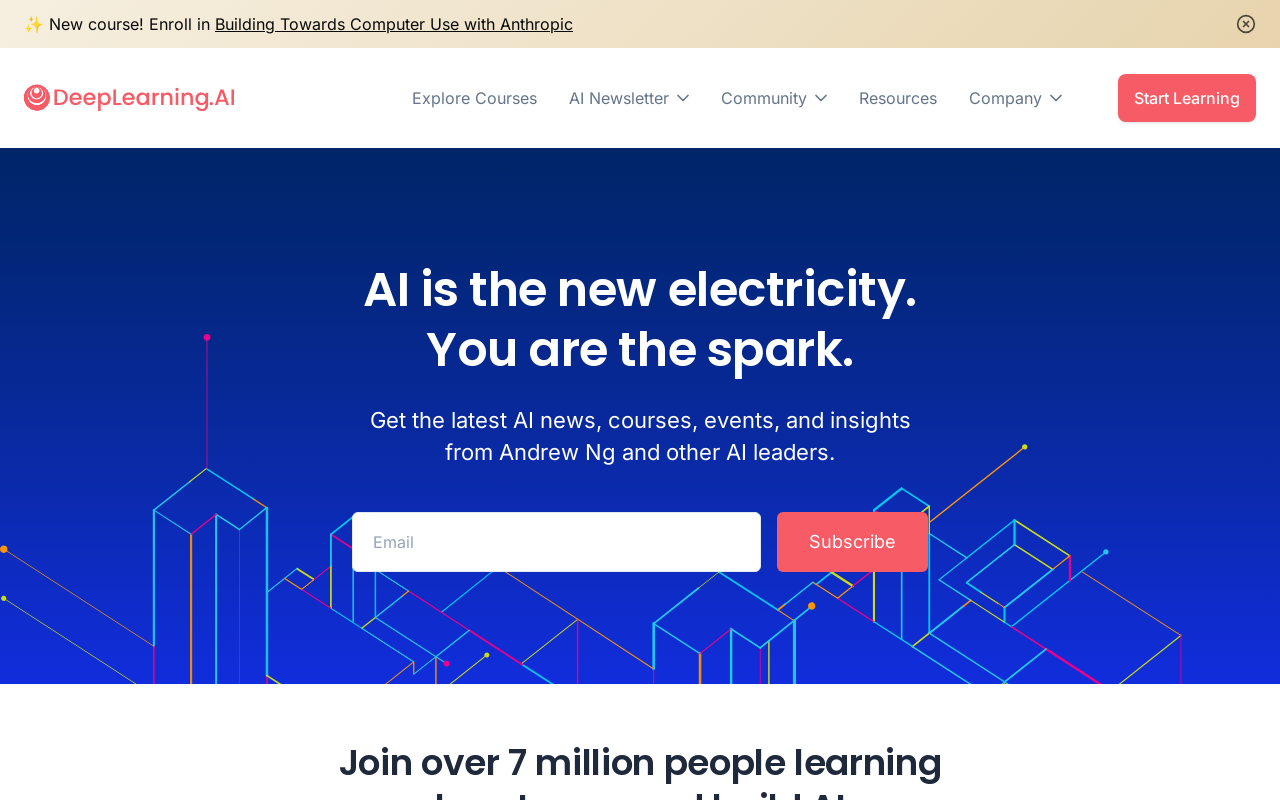

Clicking on 'Explore Courses'...
Debug - AI Response: STEP 1: AI Python for Beginners | This course is an ideal starting point for the learner, as it provides an introduction to Python programming with AI assistance. The learner will gain skills in writing, testing, and debugging code efficiently, and create real-world AI applications. This course lays the foundation for further learning in AI and LLMs, and is a prerequisite for more advanced courses. Key learnings include Python programming, AI fundamentals, and practical experience with AI applications. Connection to learning journey: This course sets the stage for the learner's exploration of LLMs and AI applications, providing a solid foundation in Python programming.

STEP 2: ChatGPT Prompt Engineering for Developers | This course is a logical next step, as it focuses on prompt engineering for ChatGPT, a crucial skill for building AI applications. The learner will learn effective prompting techniques and how to use LLMs for variou

In [ ]:
async def main():
    # Query focusing on ChatGPT and LLM development
    query = """I want to learn how to build applications using ChatGPT and LLMs.
    I'm a developer who wants to master:
    1. Prompt engineering
    2. Building AI applications
    3. Using frameworks like LangChain
    What's the recommended learning path?"""

    # Display header with query
    display(HTML("""
        <div style="margin: 20px; padding: 20px; background: linear-gradient(135deg, #3498db, #2c3e50);
                    color: white; border-radius: 15px; text-align: center;">
            <h2>🤖 AI Course Explorer</h2>
            <p style="font-style: italic; margin-top: 15px;">"{}"</p>
        </div>
    """.format(query)))

    # Start course exploration
    courses = await browse_courses(query)

# Run the query
print("Starting AI Course Explorer...")
await main()